# CNN architecture comparison

Three CNN capacities are trained with the same fixed train/tune folds and optimization settings. Classification reports and confusion matrices use only the tune fold; the test fold is not accessed.

## 1. Shared setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)

from pytorch_timecourse_classification.analysis import (
    plot_history_comparison,
    plot_training_history,
    summarize_history,
)
from pytorch_timecourse_classification.artifacts import (
    artifact_dir_for,
    load_model,
    save_experiment_artifacts,
)
from pytorch_timecourse_classification.data import load_training_folds
from pytorch_timecourse_classification.models.cnn import CNNClassifier
from pytorch_timecourse_classification.training import TrainingConfig, train

In [2]:
RANDOM_SEED = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_fold, tune_fold, preprocessor = load_training_folds()

print(f"train: {tuple(train_fold.features.shape)}")
print(f" tune: {tuple(tune_fold.features.shape)}")
print(f"classes: {preprocessor.class_names}")
print(f"device: {device}")


def generate_model(**model_config):
    torch.manual_seed(RANDOM_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_SEED)
    model = CNNClassifier(
        input_length=train_fold.features.shape[-1],
        num_classes=len(preprocessor.class_names),
        **model_config,
    )
    parameter_count = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )
    print(f"model_config: {model.model_config}")
    print(f"trainable parameters: {parameter_count:,}")
    return model, parameter_count


def train_model(model, training_config):
    print(f"training_config: {training_config}")
    return train(
        model,
        train_fold.features,
        train_fold.targets,
        tune_fold.features,
        tune_fold.targets,
        config=training_config,
        device=device,
    )


def analyze_history(history):
    plot_training_history(history)
    summary = summarize_history(history)
    print(summary)
    if summary["accuracy_gap"] > 0.10:
        print("The >10 percentage-point accuracy gap indicates overfitting.")
    elif summary["tune_accuracy"] < 0.40:
        print("Low train/tune performance suggests underfitting.")
    else:
        print("Train and tune performance are reasonably aligned.")
    return summary


def analyze_tune_confusion(model):
    model.eval()
    with torch.no_grad():
        predictions = (
            model(tune_fold.features.to(device)).argmax(dim=1).cpu().numpy()
        )
    targets = tune_fold.targets.numpy()
    print(
        classification_report(
            targets,
            predictions,
            labels=np.arange(len(preprocessor.class_names)),
            target_names=preprocessor.class_names,
            zero_division=0,
        )
    )
    ConfusionMatrixDisplay.from_predictions(
        targets,
        predictions,
        labels=np.arange(len(preprocessor.class_names)),
        display_labels=preprocessor.class_names,
        xticks_rotation=35,
        cmap="Blues",
    )
    plt.tight_layout()
    return {
        "tune_accuracy": float(np.mean(predictions == targets)),
        "tune_macro_f1": float(f1_score(targets, predictions, average="macro")),
    }


def save_and_verify(experiment_name, model, history):
    paths = save_experiment_artifacts(
        artifact_dir_for(experiment_name),
        model=model,
        history=history,
        preprocessor=preprocessor,
        training_targets=train_fold.targets,
        validation_targets=tune_fold.targets,
        device=device,
    )
    restored_model, _ = load_model(paths.model, device=device)
    for parameter_name, expected_value in model.state_dict().items():
        restored_value = restored_model.state_dict()[parameter_name]
        assert torch.equal(restored_value, expected_value), parameter_name
    with torch.no_grad():
        logits = restored_model(tune_fold.features[:16].to(device))
    assert logits.shape == (16, len(preprocessor.class_names))
    print(paths)
    return paths

train: (2790, 1, 289)
 tune: (349, 1, 289)
classes: ('0pM', '1pM', '2.5pM', '5pM', '25pM', '100pM')
device: cuda


## 2. Variant 1 — compact CNN

### 2.1 Model generation

This deliberately constrained reference uses only two small, non-residual blocks, aggressive pooling and no class balancing. It tests the underfitting/majority-class regime and provides a visibly lower-capacity anchor for the comparison.

In [3]:
compact_model, compact_parameter_count = generate_model(
    channels=(8, 16),
    kernel_sizes=(5, 3),
    dilations=(1, 1),
    pool_size=4,
    hidden_dim=16,
    dropout=0.40,
    residual=False,
)
compact_training_config = TrainingConfig(
    epochs=60, batch_size=512, learning_rate=1e-3, weight_decay=1e-3,
    scheduler_step_size=10, learning_rate_decay=0.65, patience=10,
    class_balance_strategy="none",
)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (8, 16), 'kernel_sizes': (5, 3), 'dilations': (1, 1), 'pool_size': 4, 'hidden_dim': 16, 'dropout': 0.4, 'residual': False}
trainable parameters: 870


### 2.2 Training

In [4]:
compact_history = train_model(compact_model, compact_training_config)

training_config: TrainingConfig(epochs=60, batch_size=512, learning_rate=0.001, weight_decay=0.001, scheduler_step_size=10, learning_rate_decay=0.65, patience=10, report_every=5, random_seed=42, class_balance_strategy='none', gradient_clip_norm=1.0)
epoch   1: train loss 1.85184, validation loss 1.80002, train accuracy 16.4%, validation accuracy 38.1%
epoch   5: train loss 1.74349, validation loss 1.75007, train accuracy 27.1%, validation accuracy 41.0%
epoch  10: train loss 1.67459, validation loss 1.67104, train accuracy 31.8%, validation accuracy 41.0%
epoch  15: train loss 1.62676, validation loss 1.62621, train accuracy 34.9%, validation accuracy 40.1%
epoch  20: train loss 1.56463, validation loss 1.57757, train accuracy 35.7%, validation accuracy 39.8%
epoch  25: train loss 1.54010, validation loss 1.54085, train accuracy 36.1%, validation accuracy 39.5%
epoch  30: train loss 1.50880, validation loss 1.50493, train accuracy 37.3%, validation accuracy 39.5%
epoch  35: train loss 

### 2.3 History analysis

{'epochs_run': 60, 'best_epoch': 60, 'training_loss': 1.4400449539170899, 'tune_loss': 1.4313420057296753, 'training_accuracy': 0.3913978494623656, 'tune_accuracy': 0.4040114613180516, 'accuracy_gap': -0.012613611855685991}
Train and tune performance are reasonably aligned.


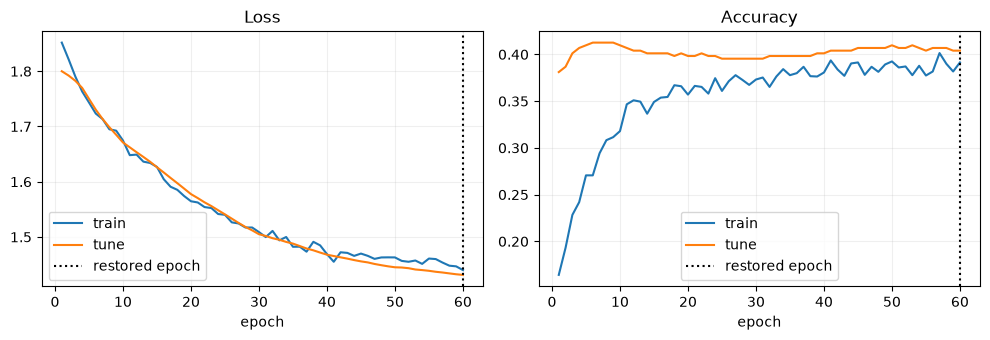

In [5]:
compact_history_summary = analyze_history(compact_history)

### 2.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.00      0.00      0.00        36
         1pM       0.41      0.96      0.57        78
       2.5pM       0.00      0.00      0.00        66
         5pM       0.25      0.08      0.12        62
        25pM       0.42      0.85      0.56        72
       100pM       0.00      0.00      0.00        35

    accuracy                           0.40       349
   macro avg       0.18      0.31      0.21       349
weighted avg       0.22      0.40      0.27       349



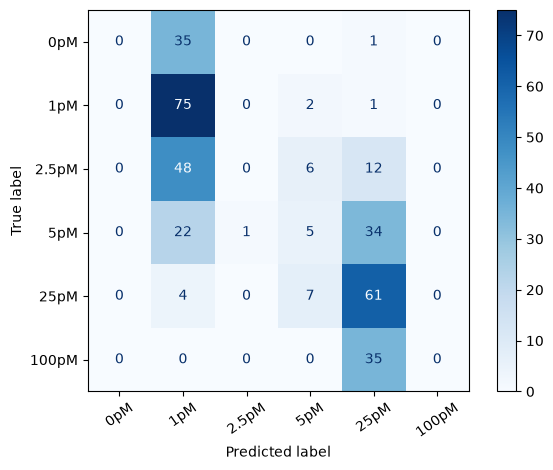

In [6]:
compact_tune_metrics = analyze_tune_confusion(compact_model)

### 2.5 Saving artifacts

In [7]:
compact_artifacts = save_and_verify("cnn_compact", compact_model, compact_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_compact/metadata.json'))


## 3. Variant 2 — baseline CNN

### 3.1 Model generation

The middle variant uses three conventional convolution blocks, moderate width and weighted loss. It adds enough capacity to learn class-specific motifs but deliberately omits residual connections and dilation, separating it from the wide model.

In [8]:
baseline_model, baseline_parameter_count = generate_model(
    channels=(16, 32, 64),
    kernel_sizes=(9, 5, 3),
    dilations=(1, 1, 1),
    pool_size=2,
    hidden_dim=32,
    dropout=0.30,
    residual=False,
)
baseline_training_config = TrainingConfig(
    epochs=100, batch_size=256, learning_rate=6e-4, weight_decay=5e-4,
    scheduler_step_size=15, learning_rate_decay=0.75, patience=15,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (16, 32, 64), 'kernel_sizes': (9, 5, 3), 'dilations': (1, 1, 1), 'pool_size': 2, 'hidden_dim': 32, 'dropout': 0.3, 'residual': False}
trainable parameters: 11,462


### 3.2 Training

In [9]:
baseline_history = train_model(baseline_model, baseline_training_config)

training_config: TrainingConfig(epochs=100, batch_size=256, learning_rate=0.0006, weight_decay=0.0005, scheduler_step_size=15, learning_rate_decay=0.75, patience=15, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.78757, validation loss 1.80352, train accuracy 20.5%, validation accuracy 6.6%
epoch   5: train loss 1.50021, validation loss 1.56984, train accuracy 28.1%, validation accuracy 21.5%
epoch  10: train loss 1.29003, validation loss 1.34778, train accuracy 39.1%, validation accuracy 36.7%
epoch  15: train loss 1.18559, validation loss 1.22996, train accuracy 43.9%, validation accuracy 42.1%
epoch  20: train loss 1.15384, validation loss 1.18892, train accuracy 44.9%, validation accuracy 47.0%
epoch  25: train loss 1.12972, validation loss 1.15830, train accuracy 46.5%, validation accuracy 48.4%
epoch  30: train loss 1.10526, validation loss 1.14361, train accuracy 47.1%, validation accuracy 50.1%
epoch  35: 

### 3.3 History analysis

{'epochs_run': 100, 'best_epoch': 96, 'training_loss': 1.0461663417918707, 'tune_loss': 1.0595094307104291, 'training_accuracy': 0.5146953405017921, 'tune_accuracy': 0.5673352435530086, 'accuracy_gap': -0.05263990305121646}
Train and tune performance are reasonably aligned.


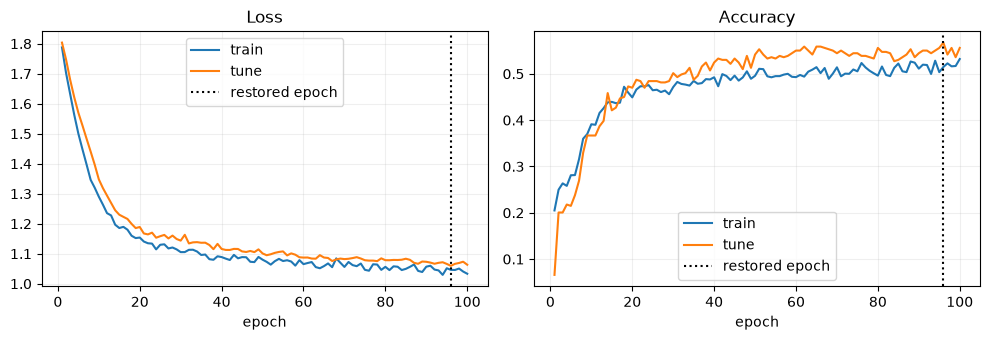

In [10]:
baseline_history_summary = analyze_history(baseline_history)

### 3.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.45      0.64      0.53        36
         1pM       0.70      0.50      0.58        78
       2.5pM       0.56      0.56      0.56        66
         5pM       0.48      0.50      0.49        62
        25pM       0.65      0.47      0.55        72
       100pM       0.58      0.97      0.72        35

    accuracy                           0.57       349
   macro avg       0.57      0.61      0.57       349
weighted avg       0.59      0.57      0.56       349



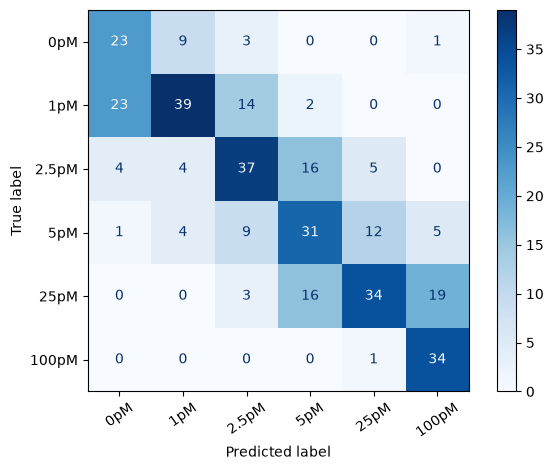

In [11]:
baseline_tune_metrics = analyze_tune_confusion(baseline_model)

### 3.5 Saving artifacts

In [12]:
baseline_artifacts = save_and_verify("cnn_baseline", baseline_model, baseline_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_baseline/metadata.json'))


## 4. Variant 3 — wide/deep CNN

### 4.1 Model generation

The high-capacity variant combines four residual blocks, wider channels, larger kernels and exponentially increasing dilations. A larger head, smaller batches and gentler regularization let it exploit the expanded temporal context.

In [13]:
wide_model, wide_parameter_count = generate_model(
    channels=(48, 96, 192, 256),
    kernel_sizes=(15, 11, 7, 5),
    dilations=(1, 2, 4, 8),
    pool_size=2,
    hidden_dim=256,
    dropout=0.15,
    residual=True,
)
wide_training_config = TrainingConfig(
    epochs=160, batch_size=128, learning_rate=3e-4, weight_decay=1e-4,
    scheduler_step_size=20, learning_rate_decay=0.85, patience=24,
    class_balance_strategy="weighted_loss",
)

model_config: {'input_length': 289, 'num_classes': 6, 'channels': (48, 96, 192, 256), 'kernel_sizes': (15, 11, 7, 5), 'dilations': (1, 2, 4, 8), 'pool_size': 2, 'hidden_dim': 256, 'dropout': 0.15, 'residual': True}
trainable parameters: 1,291,574


### 4.2 Training

In [14]:
wide_history = train_model(wide_model, wide_training_config)

training_config: TrainingConfig(epochs=160, batch_size=128, learning_rate=0.0003, weight_decay=0.0001, scheduler_step_size=20, learning_rate_decay=0.85, patience=24, report_every=5, random_seed=42, class_balance_strategy='weighted_loss', gradient_clip_norm=1.0)
epoch   1: train loss 1.24307, validation loss 1.60881, train accuracy 49.6%, validation accuracy 24.1%
epoch   5: train loss 0.77937, validation loss 1.00025, train accuracy 63.3%, validation accuracy 55.0%
epoch  10: train loss 0.61764, validation loss 1.02784, train accuracy 72.9%, validation accuracy 60.2%
epoch  15: train loss 0.55177, validation loss 0.69344, train accuracy 74.2%, validation accuracy 70.2%
epoch  20: train loss 0.47595, validation loss 0.83066, train accuracy 76.8%, validation accuracy 68.5%
epoch  25: train loss 0.35703, validation loss 0.95973, train accuracy 81.9%, validation accuracy 64.2%
epoch  30: train loss 0.28262, validation loss 0.88244, train accuracy 85.0%, validation accuracy 66.8%
epoch  35:

### 4.3 History analysis

{'epochs_run': 39, 'best_epoch': 15, 'training_loss': 0.5517681943472995, 'tune_loss': 0.693443392272665, 'training_accuracy': 0.7419354838709677, 'tune_accuracy': 0.7020057306590258, 'accuracy_gap': 0.03992975321194192}
Train and tune performance are reasonably aligned.


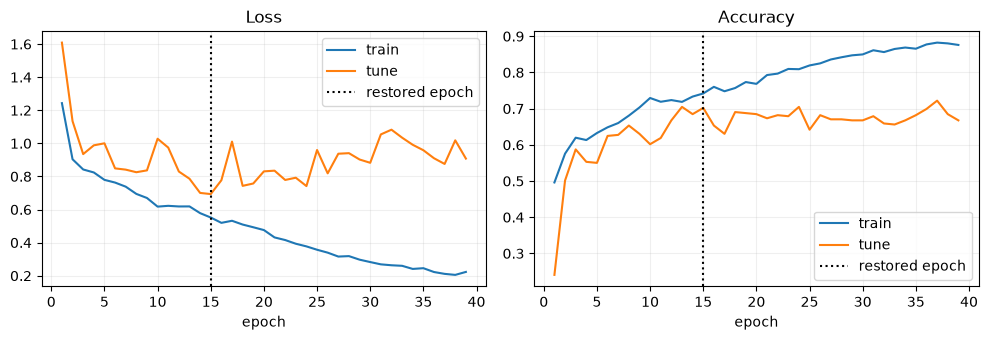

In [15]:
wide_history_summary = analyze_history(wide_history)

### 4.4 Tune confusion analysis

              precision    recall  f1-score   support

         0pM       0.44      0.78      0.57        36
         1pM       0.70      0.56      0.62        78
       2.5pM       0.73      0.68      0.70        66
         5pM       0.77      0.53      0.63        62
        25pM       0.81      0.86      0.83        72
       100pM       0.80      0.94      0.87        35

    accuracy                           0.70       349
   macro avg       0.71      0.73      0.70       349
weighted avg       0.72      0.70      0.70       349



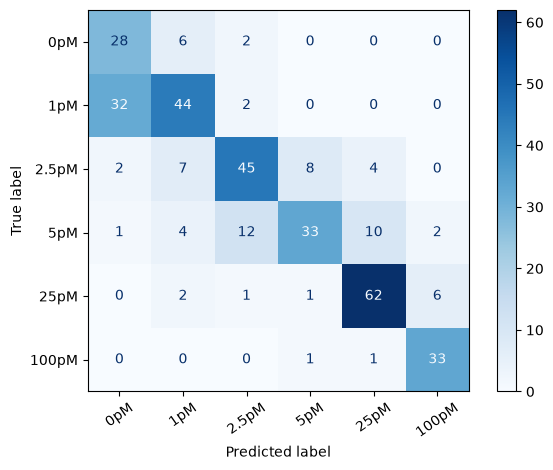

In [16]:
wide_tune_metrics = analyze_tune_confusion(wide_model)

### 4.5 Saving artifacts

In [17]:
wide_artifacts = save_and_verify("cnn_wide", wide_model, wide_history)

ArtifactPaths(model=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/model.pt'), history=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/training_history.npz'), metadata=PosixPath('/home/lorenz/Environments/DeeplearningExamples/projects/pytorch_timecourse_classification/notebooks/artifacts/cnn_wide/metadata.json'))


## 5. Direct comparison

Tune macro-F1 is the primary comparison metric because the classes are imbalanced. Parameter count and the train–tune gap indicate whether a small improvement justifies additional capacity.

In [18]:
comparison = pd.DataFrame(
    [
        {
            "variant": "compact",
            "parameters": compact_parameter_count,
            **compact_history_summary,
            **compact_tune_metrics,
        },
        {
            "variant": "baseline",
            "parameters": baseline_parameter_count,
            **baseline_history_summary,
            **baseline_tune_metrics,
        },
        {
            "variant": "wide",
            "parameters": wide_parameter_count,
            **wide_history_summary,
            **wide_tune_metrics,
        },
    ]
).set_index("variant")
comparison.round(4)

,parameters,epochs_run,best_epoch,training_loss,tune_loss,training_accuracy,tune_accuracy,accuracy_gap,tune_macro_f1
variant,,,,,,,,,
compact,870,60,60,1.4400,1.4313,0.3914,0.4040,-0.0126,0.2099
baseline,11462,100,96,1.0462,1.0595,0.5147,0.5673,-0.0526,0.5719
wide,1291574,39,15,0.5518,0.6934,0.7419,0.7020,0.0399,0.7037


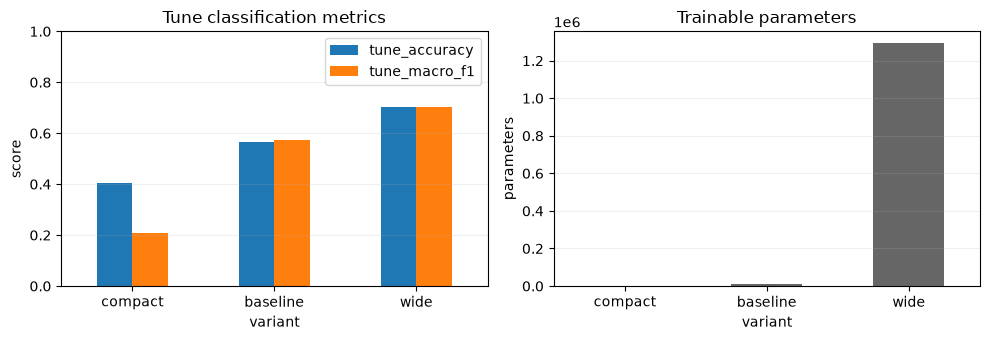

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.5))
comparison[["tune_accuracy", "tune_macro_f1"]].plot.bar(
    ax=axes[0], ylim=(0, 1), rot=0
)
axes[0].set(title="Tune classification metrics", ylabel="score")
comparison["parameters"].plot.bar(ax=axes[1], color="0.4", rot=0)
axes[1].set(title="Trainable parameters", ylabel="parameters")
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
figure.tight_layout()

### Interpretation and next steps

The new configurations deliberately span three regimes. In a fixed-seed pilot run, the compact CNN reached only about 0.40 tune accuracy and 0.21 macro-F1. Its two tiny blocks, aggressive pooling and unweighted loss make it a clear underfitting/majority-class reference rather than a serious final candidate. A small train–tune gap here is not evidence of good generalization; both folds can simply be fitted inadequately.

The conventional three-block baseline forms a genuine middle tier: the same pilot reached about 0.57 tune accuracy and 0.57 macro-F1. Weighted loss recovers substantially more minority-class performance, while the lack of residual/dilated blocks limits capacity and temporal context. The wide/deep model reached about 0.69 tune accuracy and 0.70 macro-F1. Its gain therefore tests a meaningful architectural step—residual optimization and a much larger dilated receptive field—not width alone.

Use the rerun histories—not the intended capacity ordering—to diagnose overfitting. Train metrics are recorded with dropout and batch normalization in training mode, whereas tune metrics use evaluation mode, so loss curves and the restored minimum-tune-loss epoch are more reliable than a small accuracy gap. The wide pilot stopped early and restored an earlier checkpoint, which indicates that its extra capacity can overfit even though its restored tune score is strongest.

The approximately 0.21 → 0.57 → 0.70 pilot macro-F1 progression is intentionally easier to interpret, but it is still one seed on one fixed tune fold. Rerun the notebook to replace the cleared outputs, then repeat every candidate with several seeds before accepting the ranking. If the goal changes from illustration to fair architecture selection, equalize the class-balancing strategy and optimization budget across variants. Finally, use group-aware splitting if multiple cells share experiment-level effects; label stratification alone cannot prevent such leakage.

## 6. Training-history comparison

The four panels compare train and tune loss and accuracy for all three CNN variants. Each dot marks the checkpoint epoch restored after early stopping.

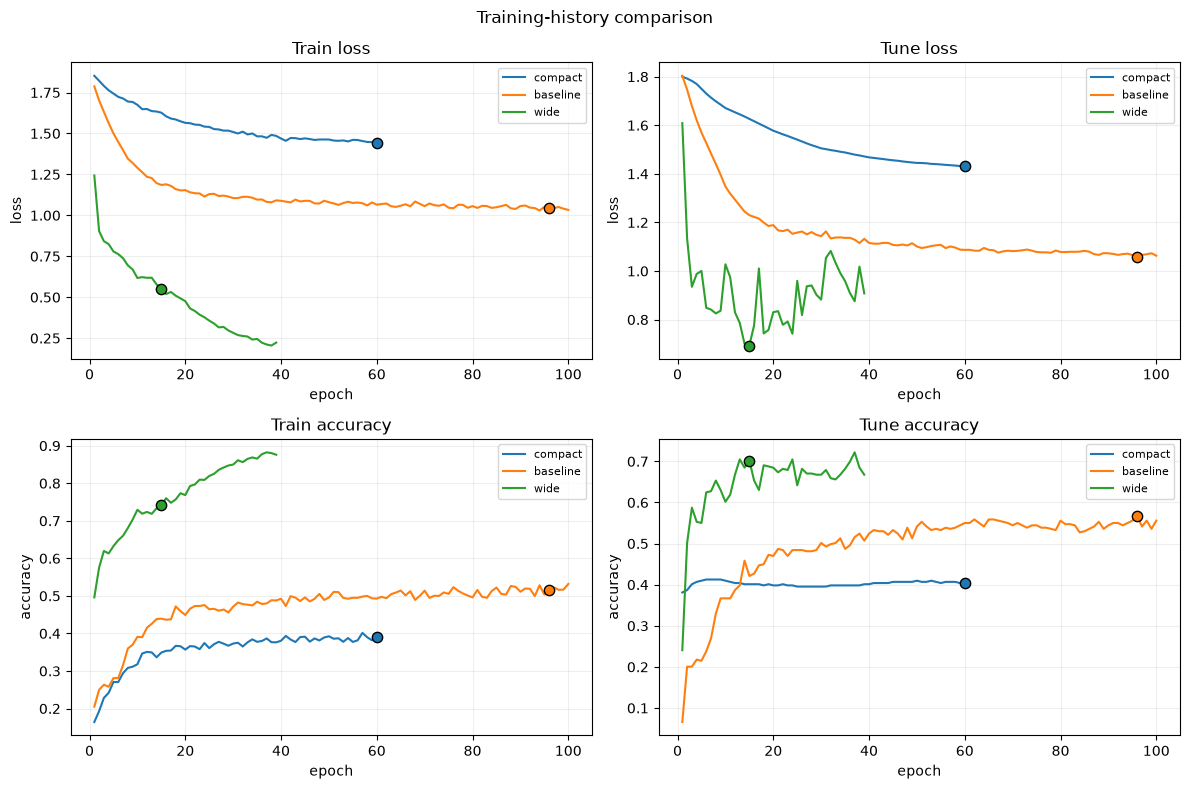

In [20]:
history_comparison_figure = plot_history_comparison({
    "compact": compact_history,
    "baseline": baseline_history,
    "wide": wide_history,
})